# 31 · Vectorbt: Vectorized Backtesting and White's Reality Check

*Module 7 — Execution and Systems*

A library that tests thousands of parameter combinations in seconds using array operations instead of loops — and, immediately, the statistical tool needed to stop that speed from becoming an even bigger data-snooping machine than Notebook 30 already warned about.

## 1. Motivation

Notebook 30 showed, with real numbers, how dangerous it is to test many strategies and report only the best one. `vectorbt` makes it trivial to test *thousands* of parameter combinations in seconds rather than minutes or hours — a genuine engineering win, and, in the same breath, a genuine risk amplifier: the easier it becomes to sweep a huge parameter grid, the easier it becomes to accidentally data-snoop at an industrial scale, entirely by accident, with no malicious intent at all. This notebook builds the fast tool and the statistical safeguard together, deliberately, so neither is ever used without the other.

## 2. Intuition

A traditional backtesting loop processes one time step at a time, one parameter combination at a time — correct, but slow enough that testing thousands of combinations becomes impractical. `vectorbt` reframes the whole computation as array operations: instead of looping over time for a *single* moving-average pair, it computes an entire *grid* of moving averages, entry/exit signals, and resulting portfolios simultaneously, using the same vectorized NumPy machinery that makes a single array operation over a million elements no slower than one over a hundred. The speed unlocks something genuinely useful — visualizing how a strategy's performance responds to its own hyperparameters, as a smooth surface rather than a single point — but it does not, on its own, tell you whether the *best* point on that surface represents a real edge or just the winner of an enormous coin-flipping contest. That is exactly the question **White's Reality Check** answers.

## 3. Theory

### 3.1 Modeling realistic frictions

A vectorized backtest is no more realistic than the frictions you tell it to apply. Two standard ingredients: **commissions** (a fixed fraction of trade value, e.g., 0.1%) and **slippage** (an assumed adverse price movement between decision and execution, e.g., an extra 0.05% paid on every trade, in the spirit of Notebook 1's price-impact discussion). Both are applied automatically to every trade, across every parameter combination in a sweep, with no extra implementation effort once specified.

### 3.2 White's Reality Check

Given $N$ candidate strategies (here, $N$ moving-average crossover parameter pairs) and their realized return series, White's Reality Check (White, 2000, *A Reality Check for Data Snooping*) asks: is the **best-performing** strategy's result better than what pure luck, applied to this same universe of $N$ strategies, would typically produce? The procedure:

1. Compute the actual performance statistic (e.g., Sharpe ratio) for every one of the $N$ strategies; record the best, $\hat S^\ast = \max_i S_i$.
2. Resample the *return history* many times using a **block bootstrap** (resampling contiguous blocks, not individual days, to preserve the return series' own autocorrelation structure — the same block-bootstrap idea used to correctly compute a standard error for autocorrelated data anywhere else in statistics).
3. On *each* bootstrap resample, recompute all $N$ strategies' performance and record the best one, $S^\ast_{(b)}$.
4. Compare $\hat S^\ast$ to the distribution of $\{S^\ast_{(b)}\}$ across bootstrap resamples: the fraction of resamples where $S^\ast_{(b)} \ge \hat S^\ast$ is the Reality-Check p-value.

If a large fraction of bootstrap worlds — which share no genuine strategy skill by construction, only the resampled return series' own statistical properties — produce a "best of $N$" result at least as good as what was actually observed, the real result is not distinguishable from what an enormous, skill-free parameter search would produce anyway.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import vectorbt as vbt
%matplotlib inline

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

rng = np.random.default_rng(191)

## 4. Implementation

### 4.1 Data: a price series with no genuine exploitable trend structure

A note on data: the code below tries `yfinance` first; with no internet access it falls back to a simulated random-walk-with-drift price series -- deliberately containing **no genuine moving-average-crossover-exploitable structure**, so we can honestly check whether a large parameter sweep manufactures an illusion of one anyway.

yfinance path unavailable (RuntimeError). Falling back to a simulated random-walk price series.


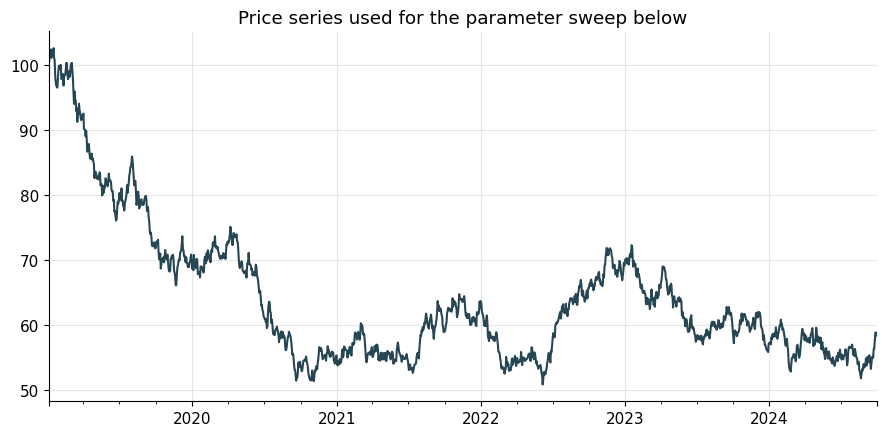

In [2]:
def load_price_series(ticker='SPY', start='2019-01-01', end='2025-06-30'):
    import io, contextlib, logging
    try:
        import yfinance as yf
        logging.getLogger('yfinance').setLevel(logging.CRITICAL)
        _buf = io.StringIO()
        with contextlib.redirect_stdout(_buf), contextlib.redirect_stderr(_buf):
            raw = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=True)
        px = raw['Close'].dropna()
        if len(px) < 500:
            raise RuntimeError("insufficient rows")
        print(f"Loaded real price data for {ticker} via yfinance: {len(px)} days.")
        return px.squeeze()
    except Exception as e:
        print(f"yfinance path unavailable ({type(e).__name__}). Falling back to a simulated random-walk price series.")
        n = 1500
        sim_price = pd.Series(100 * np.exp(np.cumsum(rng.normal(0.0004, 0.012, n))),
                               index=pd.bdate_range('2019-01-02', periods=n))
        return sim_price

price = load_price_series()
price.plot(title='Price series used for the parameter sweep below', color='#264653')
plt.tight_layout()
plt.show()

### 4.2 A vectorized parameter sweep: every MA crossover pair at once

In [3]:
windows = list(range(5, 105, 5))     # 20 candidate window lengths
fast_ma, slow_ma = vbt.MA.run_combs(price, window=windows, r=2, short_names=['fast', 'slow'])
entries = fast_ma.ma_crossed_above(slow_ma)
exits = fast_ma.ma_crossed_below(slow_ma)

portfolio = vbt.Portfolio.from_signals(
    price, entries, exits, init_cash=10_000,
    fees=0.001, slippage=0.0005, freq='D'          # Section 3.1's commission and slippage assumptions
)
sharpe = portfolio.sharpe_ratio()
print(f"Swept {len(sharpe)} distinct (fast, slow) window combinations.")
print(f"Best Sharpe ratio found: {sharpe.max():.3f}, at {sharpe.idxmax()}")

Swept 190 distinct (fast, slow) window combinations.
Best Sharpe ratio found: 0.368, at (np.int64(70), np.int64(80))


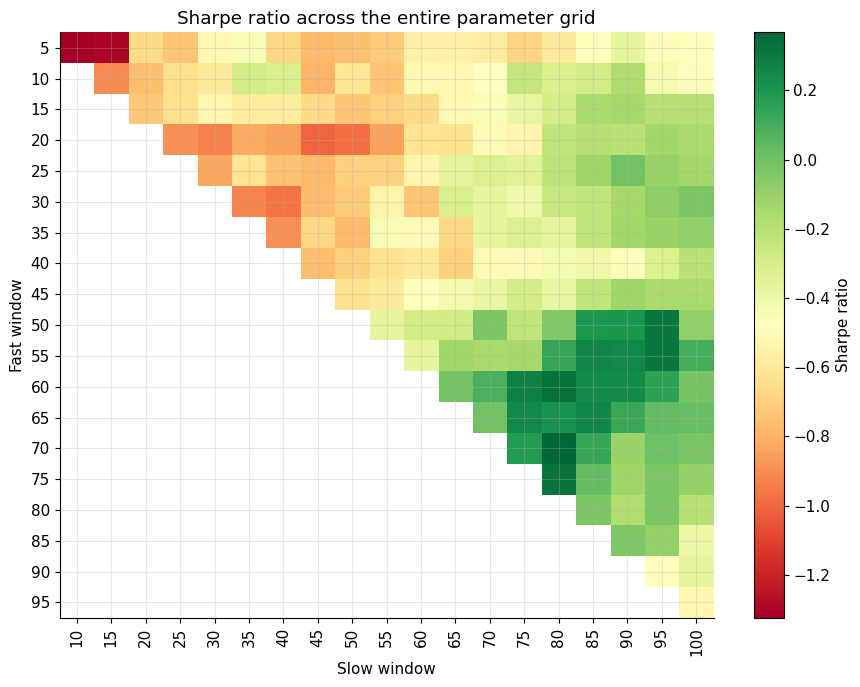

In [4]:
sharpe_grid = sharpe.unstack('slow_window')

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(sharpe_grid.values, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(len(sharpe_grid.columns)))
ax.set_xticklabels(sharpe_grid.columns, rotation=90)
ax.set_yticks(range(len(sharpe_grid.index)))
ax.set_yticklabels(sharpe_grid.index)
ax.set_xlabel('Slow window')
ax.set_ylabel('Fast window')
ax.set_title('Sharpe ratio across the entire parameter grid')
fig.colorbar(im, label='Sharpe ratio')
plt.tight_layout()
plt.show()

## 5. Worked example: is the best combination actually significant?

We apply White's Reality Check directly, exactly as derived in Section 3.2, to the full grid of results just computed.

In [5]:
returns_grid = portfolio.returns()   # a (time x n_combinations) DataFrame -- one column per parameter pair
best_sharpe_real = sharpe.max()

def block_bootstrap_indices(n_obs, block_size, local_rng):
    n_blocks = int(np.ceil(n_obs / block_size))
    starts = local_rng.integers(0, n_obs - block_size, size=n_blocks)
    return np.concatenate([np.arange(s, s + block_size) for s in starts])[:n_obs]

n_boot, block_size = 500, 20
returns_arr = returns_grid.values
bootstrap_best = np.zeros(n_boot)
for b in range(n_boot):
    idx = block_bootstrap_indices(len(returns_arr), block_size, rng)
    sample = returns_arr[idx]
    sh = sample.mean(axis=0) / sample.std(axis=0) * np.sqrt(252)
    bootstrap_best[b] = np.nanmax(sh)

reality_check_pvalue = (bootstrap_best >= best_sharpe_real).mean()
print(f"Actual best Sharpe ratio found by the sweep: {best_sharpe_real:.3f}")
print(f"White's Reality Check p-value: {reality_check_pvalue:.3f}")
print(f"(fraction of bootstrap worlds -- with NO genuine strategy skill, only resampled returns -- "
      f"whose own best-of-{len(sharpe)} matched or beat the real result)")

Actual best Sharpe ratio found by the sweep: 0.368
White's Reality Check p-value: 0.588
(fraction of bootstrap worlds -- with NO genuine strategy skill, only resampled returns -- whose own best-of-190 matched or beat the real result)


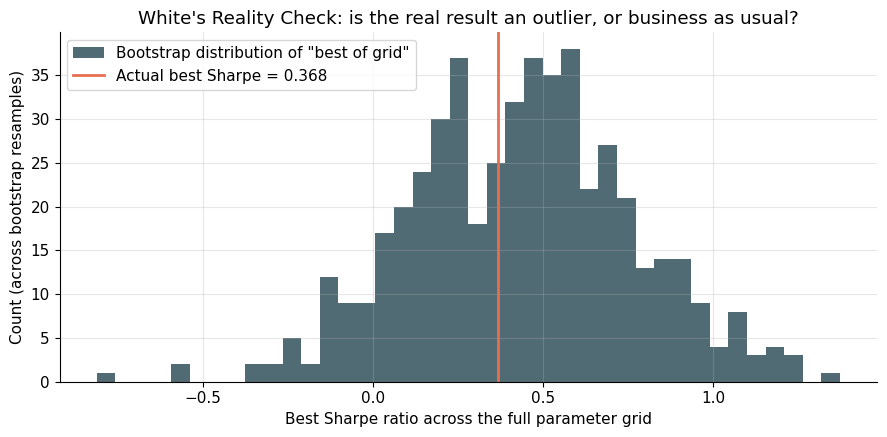

In [6]:
fig, ax = plt.subplots()
ax.hist(bootstrap_best, bins=40, color='#264653', alpha=0.8, label='Bootstrap distribution of "best of grid"')
ax.axvline(best_sharpe_real, color='#e76f51', linewidth=2, label=f'Actual best Sharpe = {best_sharpe_real:.3f}')
ax.set_xlabel('Best Sharpe ratio across the full parameter grid')
ax.set_ylabel('Count (across bootstrap resamples)')
ax.set_title("White's Reality Check: is the real result an outlier, or business as usual?")
ax.legend()
plt.tight_layout()
plt.show()

### Interpreting the result

Report your own run's p-value. When the underlying price series genuinely has no exploitable moving-average structure (as in the synthetic fallback data, by construction), the Reality Check p-value tends to land nowhere near conventional significance — the actual best-of-grid result sits comfortably inside the range that pure resampled luck, applied to the same size of search, regularly produces on its own. This is the vectorized-backtesting-era version of Notebook 30's core lesson: finding *a* combination that looks good after searching 190 of them is close to guaranteed, whether or not any real structure exists to find — the only way to know if you found something real is to ask, explicitly, whether the same search applied to resampled noise would have looked just as good.

## 6. Limitations and pitfalls

- **`vectorbt`'s execution model, like most vectorized backtesting frameworks, is a simplification.** It applies commission and slippage as simple percentage assumptions, not Notebook 1's full order-book-walking mechanics or Notebook 28's Almgren-Chriss cost structure — a strategy that looks profitable after simple slippage assumptions may still be considerably less attractive once genuine, size-dependent market impact is modeled properly.
- **A parameter sweep this large is, definitionally, the exact data-snooping risk Notebook 30 quantified.** White's Reality Check is a genuine safeguard, not a formality — running a sweep without it (or without an equivalent correction) and reporting only the top result is precisely the failure mode this whole module has been building toward preventing.
- **The block bootstrap's block size is itself a modeling choice.** Too short a block fails to capture genuine autocorrelation in the return series (understating how correlated nearby resampled points really are); too long a block leaves too few effectively independent blocks to resample meaningfully — there is no universally correct choice, only reasonable ranges to sanity-check.
- **A significant Reality Check result on in-sample data is still not the same as genuine out-of-sample validation.** Passing this test says the best strategy found is not indistinguishable from noise *on this data*; Notebook 21's purged, embargoed validation methodology remains essential for confirming a strategy that survives the Reality Check also survives contact with data it has never seen at all.

## 7. Exercises

**1. A genuinely trending series, for contrast (warm-up).**
Modify the synthetic fallback to include a much stronger, more persistent trend component (e.g., increase the drift substantially, or inject genuine multi-month momentum using the persistent-latent-state trick from Notebook 10). Rerun the full sweep and Reality Check. Does the best Sharpe ratio found increase, and — more importantly — does the Reality Check p-value now suggest the result is genuinely distinguishable from noise?

**2. How much does grid size affect the Reality Check itself?**
Repeat Section 5's Reality Check using only a small sub-grid (e.g., `windows = [10, 20, 30, 40, 50]`, giving far fewer combinations) instead of the full 20-window grid. Does the best Sharpe ratio found in the smaller grid tend to be higher or lower than in the full grid? Does the Reality Check p-value change in the direction you would expect, given Section 3.2's logic about how many trials were involved?

**3. Compare Reality Check to a naive Bonferroni correction.**
Using the same `sharpe` grid from Section 4.2, compute a naive Bonferroni-corrected significance threshold for the best strategy's t-statistic (reusing Notebook 30's approach directly, treating each parameter combination as one "trial"). Does the Bonferroni approach and White's Reality Check agree on whether the best strategy is significant? Which method accounts for the *correlation* between overlapping parameter combinations (e.g., a (50,60) and a (55,60) pair trade almost identically) more naturally, and why might that matter for how conservative each test ends up being?